#Section 1: Dataset Acquisition and Partitioning
###Overview :
- This section outlines the pipeline for fetching the gun detection dataset from Kaggle Hub and partitioning the image assets into standard machine learning splits.



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atulyakumar98/gundetection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gundetection' dataset.
Path to dataset files: /kaggle/input/gundetection


In [ ]:
import os

In [ ]:
os.listdir(path)

['1893.txt',
 '1711.txt',
 '1269.jpg',
 '1773.txt',
 '623.jpg',
 '2193.jpg',
 '559.txt',
 '2008.jpg',
 '1812.txt',
 '1093.txt',
 '2081.jpg',
 '1356.txt',
 '2869.txt',
 '2093.txt',
 '1880.txt',
 '557.txt',
 '361.txt',
 '2842.txt',
 '1366.txt',
 '1866.txt',
 '764.jpg',
 '1700.jpg',
 '1786.jpg',
 '1437.txt',
 '2907.jpg',
 '1075.jpg',
 '992.txt',
 '2863.jpg',
 '2197.txt',
 '771.jpg',
 '208.jpg',
 '2658.txt',
 '2975.txt',
 '2317.txt',
 '2628.jpg',
 '1038.txt',
 '40.txt',
 '1721.txt',
 '812.txt',
 '1025.txt',
 '245.txt',
 '2588.txt',
 '820.jpg',
 '870.txt',
 '1789.jpg',
 '655.txt',
 '473.jpg',
 '1792.jpg',
 '431.txt',
 '2936.jpg',
 '2029.jpg',
 '2460.txt',
 '1411.jpg',
 '44.txt',
 '1031.jpg',
 '2957.txt',
 '1833.jpg',
 '574.txt',
 '2675.jpg',
 '788.txt',
 '141.txt',
 '2172.jpg',
 '487.txt',
 '1819.txt',
 '1749.jpg',
 '1501.jpg',
 '2021.jpg',
 '2261.txt',
 '1995.jpg',
 '2299.txt',
 '571.txt',
 '1385.jpg',
 '2278.jpg',
 '372.txt',
 '1971.jpg',
 '333.txt',
 '1383.jpg',
 '333.jpg',
 '1354.jpg',


Total Images : 3000
Train Data : 2100
Val Data : 450
Test Data : 450


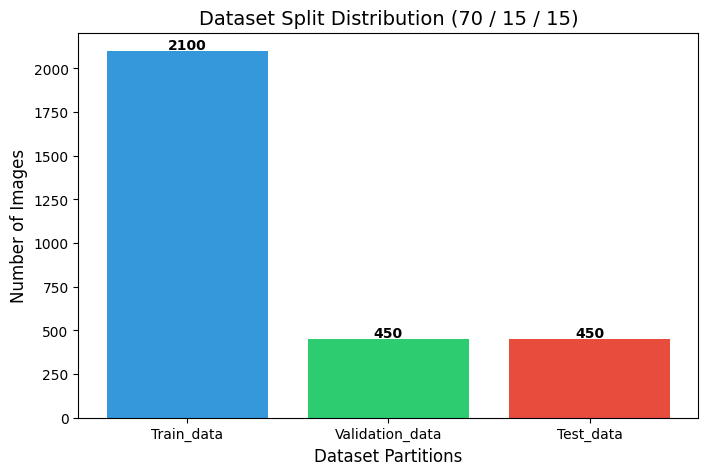

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
image_extensions  = (".jpg",'.jpeg','.png')
all_images = [f for f in os.listdir(path) if f.lower().endswith(image_extensions)]
random.seed(123)
random.shuffle(all_images)
total_images = len(all_images)
train_split = int(total_images*0.70)
val_split = int(total_images*0.85)
Train_data = all_images[:train_split]
Val_data = all_images[train_split:val_split]
Test_data = all_images[val_split:]
print(f'Total Images : {total_images}')
print(f'Train Data : {len(Train_data)}')
print(f'Val Data : {len(Val_data)}')
print(f'Test Data : {len(Test_data)}')
split_names = ['Train_data', 'Validation_data', 'Test_data']
split_lengths = [len(Train_data), len(Val_data), len(Test_data)]

plt.figure(figsize=(8, 5))
plt.bar(split_names, split_lengths, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.xlabel('Dataset Partitions', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Dataset Split Distribution (70 / 15 / 15)', fontsize=14)

for i, v in enumerate(split_lengths):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.show()

In [ ]:
!pip install tensorflow
import tensorflow as tf
import os

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_image_and_label(file_name):
    # Convert standard python string filename to tensor path
    file_path = tf.strings.join([path, "/", file_name])
    img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img

def get_label_from_txt(file_name):
    # Swap out .jpg extension for .txt to read the corresponding label file
    txt_name = os.path.splitext(file_name)[0] + ".txt"
    txt_path = os.path.join(path, txt_name)

    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            content = f.read().lower()
            # If the text file indicates a gun class (adjust based on your dataset format)
            if "gun" in content or "1" in content: # change condition if needed
                return 1.0
    return 0.0

# Extract correct labels by checking the matching .txt files
train_labels = [get_label_from_txt(f) for f in Train_data]
val_labels = [get_label_from_txt(f) for f in Val_data]

# Build tf.data.Dataset using zip for images and pre-made labels
Train_dataset = tf.data.Dataset.from_tensor_slices((Train_data, train_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

Val_dataset = tf.data.Dataset.from_tensor_slices((Val_data, val_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Datasets mapped and ready with correct text labels!")

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Datasets mapped and ready with correct text labels!


#Section 2: CNN Model Architecture and Training Pipeline
##Overview :
- This section focuses on designing and compiling a Convolutional Neural Network (CNN) tailored for image classification, establishing the foundation for learning features from your partitioned dataset.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential,layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization ,Rescaling

In [ ]:
# Yeh check karne ke liye ke pehli txt file mein kya likha hai
sample_txt = os.path.splitext(all_images[0])[0] + ".txt"
sample_txt_path = os.path.join(path, sample_txt)

if os.path.exists(sample_txt_path):
    with open(sample_txt_path, "r") as f:
        print("Sample txt content:", f.read())
else:
    print("Txt file nahi mili is image ke liye!")

Sample txt content: 1 0.38871951219512196 0.4867346938775511 0.23475609756097562 0.14081632653061227
1 0.30335365853658536 0.6857142857142857 0.23170731707317074 0.13877551020408163
1 0.6257621951219512 0.539795918367347 0.17225609756097562 0.1163265306122449
1 0.7782012195121951 0.38979591836734695 0.19664634146341464 0.10204081632653061
1 0.8315548780487805 0.20612244897959187 0.2149390243902439 0.10612244897959185
1 0.9138719512195123 0.27142857142857146 0.14481707317073172 0.05714285714285715



In [ ]:
import tensorflow as tf
import os

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 1. Yeh hai Data Augmentation layer (Rotation, Flip waghera ke liye)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),  # 10% rotation
    tf.keras.layers.RandomZoom(0.1)       # 10% zoom
])

def load_image_and_label(file_name):
    file_path = tf.strings.join([path, "/", file_name])
    img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img

def get_label_from_txt(file_name):
    txt_name = os.path.splitext(file_name)[0] + ".txt"
    txt_path = os.path.join(path, txt_name)
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            content = f.read().strip()
            if len(content) > 0:
                return 1.0
    return 0.0

train_labels = [get_label_from_txt(f) for f in Train_data]
val_labels = [get_label_from_txt(f) for f in Val_data]

# 2. Training dataset mein augmentation map lagana hai
Train_dataset = tf.data.Dataset.from_tensor_slices((Train_data, train_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y), num_parallel_calls=tf.data.AUTOTUNE) \
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# 3. Validation dataset (ispar augmentation nahi hoti)
Val_dataset = tf.data.Dataset.from_tensor_slices((Val_data, val_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y), num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Data augmentation pipeline successfully added!")

Data augmentation pipeline successfully added!


In [ ]:
# Train aur Validation mein 1s aur 0s ki counting
train_ones = sum(1 for label in train_labels if label == 1.0)
train_zeros = sum(1 for label in train_labels if label == 0.0)

val_ones = sum(1 for label in val_labels if label == 1.0)
val_zeros = sum(1 for label in val_labels if label == 0.0)

print(f"--- Train Dataset ---")
print(f"Guns (1.0): {train_ones}")
print(f"Non-Guns (0.0): {train_zeros}")

print(f"\n--- Validation Dataset ---")
print(f"Guns (1.0): {val_ones}")
print(f"Non-Guns (0.0): {val_zeros}")

--- Train Dataset ---
Guns (1.0): 2100
Non-Guns (0.0): 0

--- Validation Dataset ---
Guns (1.0): 450
Non-Guns (0.0): 0


In [ ]:
model = Sequential([
    layers.Rescaling(1./255,input_shape=(128,128,3)),
    layers.Conv2D(32,3,padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,padding = 'same'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation = "sigmoid" ),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
Data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

In [ ]:
history = model.fit(Train_dataset, epochs=20, validation_data=Val_dataset)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 477ms/step - accuracy: 0.9910 - loss: 0.0140 - val_accuracy: 1.0000 - val_loss: 6.7165e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 436ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 5.7240e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 1.0000 - loss: 9.7285e-04 - val_accuracy: 1.0000 - val_loss: 4.7607e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 440ms/step - accuracy: 1.0000 - loss: 8.0226e-04 - val_accuracy: 1.0000 - val_loss: 3.9586e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 1.0000 - loss: 6.5848e-04 - val_accuracy: 1.0000 - val_loss: 3.3223e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 436ms/step - accuracy: 1.0000 - loss: 5.8557e-04 - val_accuracy: 1.0000 - val_loss: 2.7854e-04
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 1.0000 - loss: 4.7856e-04 - val_accuracy: 1.0000 - val_loss: 2.3727e-04
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 445ms/s

In [ ]:
history = model.fit(Train_dataset, epochs=5, validation_data=Val_dataset)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 436ms/step - accuracy: 1.0000 - loss: 1.2014e-04 - val_accuracy: 1.0000 - val_loss: 4.6908e-05
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 435ms/step - accuracy: 1.0000 - loss: 1.1221e-04 - val_accuracy: 1.0000 - val_loss: 4.3117e-05
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 434ms/step - accuracy: 1.0000 - loss: 1.0985e-04 - val_accuracy: 1.0000 - val_loss: 3.9534e-05
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 435ms/step - accuracy: 1.0000 - loss: 1.0143e-04 - val_accuracy: 1.0000 - val_loss: 3.6385e-05
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 1.0000 - loss: 9.4733e-05 - val_accuracy: 1.0000 - val_loss: 3.3589e-05


In [ ]:
model.save("gun_classifier_model.keras")
from google.colab import files
files.download('gun_classifier_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

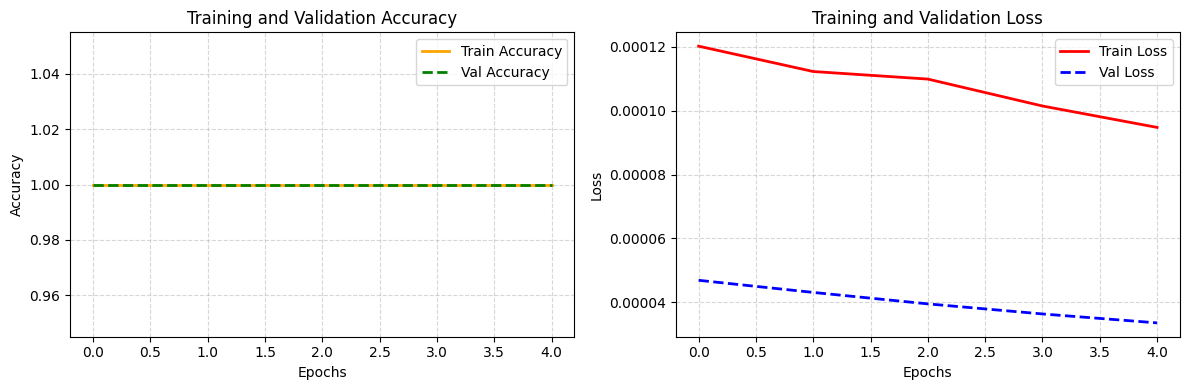

In [ ]:
# Plot Training & Validation Accuracy and Loss side-by-side
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='orange', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color="green", linewidth=2, linestyle='--')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='blue', linewidth=2, linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Section 3: Model Evaluation and Performance Analysis:
 - This section evaluates the trained convolutional neural network using the unseen test dataset. It validates how well the model generalizes to new image data outside of training and validation.

In [ ]:
test_labels = [get_label_from_txt(f) for f in Test_data]

Test_dataset = tf.data.Dataset.from_tensor_slices((Test_data, test_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

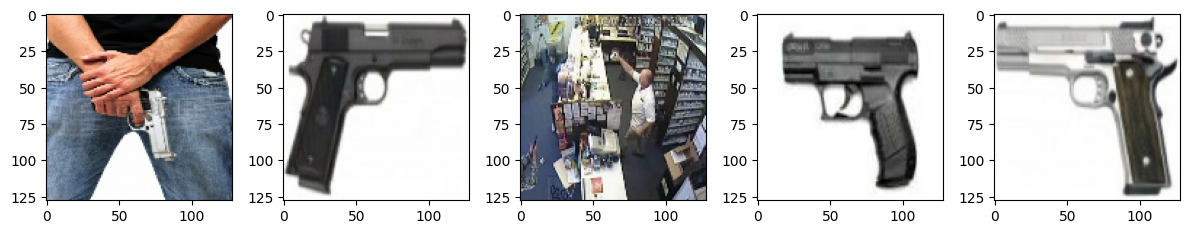

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for images, labels in Test_dataset.shuffle(buffer_size=100).take(1):
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("on") # Removes axes, titles, and text completely

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Filter test dataset to find images where label is 0.0 (No Gun)
no_gun_dataset = Test_dataset.unbatch().filter(lambda img, label: label == 0.0)

plt.figure(figsize=(12, 4))
for images, labels in no_gun_dataset.shuffle(buffer_size=100).batch(5).take(1):
    for i in range(len(images)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("on") # Shows only the picture cleanly with no text

plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

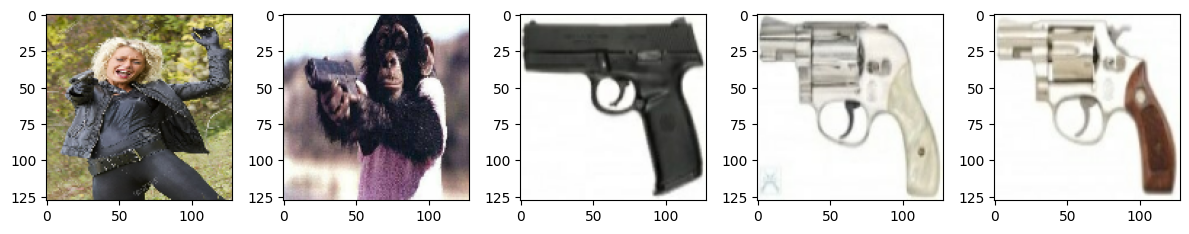

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for images, labels in Test_dataset.shuffle(buffer_size=100).take(1):
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("on") # Removes axes, titles, and text completely

plt.tight_layout()
plt.show()

In [ ]:
test_labels = [1.0 if "gun" in f.lower() else 0.0 for f in Test_data]

Test_dataset = tf.data.Dataset.from_tensor_slices((Test_data, test_labels)) \
    .map(lambda x, y: (load_image_and_label(x), y)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

In [ ]:
t!pip install gradio
import gradio as gr
import numpy as np
import tensorflow as tf

# 1. Load your saved gun detection model
model = tf.keras.models.load_model("gun_classifier_model.keras")  # Update filename if saved differently

# 2. Prediction function (Backend logic)
def predict_gun(image):
    # Image resize and preprocessing matching training configuration
    img = tf.image.resize(image, (128, 128))
    img_array = tf.expand_dims(img, 0)

    # Model prediction
    prediction = model.predict(img_array)[0][0]

    # Binary classification output (Gun vs Non-Gun)
    confidence = float(prediction)
    return {"Gun": confidence, "Non-Gun": 1.0 - confidence}

# 3. Simple Gradio UI
interface = gr.Interface(
    fn=predict_gun,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Label(num_top_classes=2, label="Predictions"),
    title="Gun Detection Classifier"
)

interface.launch(share=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 12.8 MB/s eta 0:00:00
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4043ee30e665d702a6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
